# FARMWISE empirical evaluation - analysis

This notebook only **analyses a frozen collection** written by
`python -m evaluation.collect_empirical`; it never queries live APIs. Set
`COLLECTION_ID` to the collection used in the paper so that every table and
figure below can be regenerated from the preserved files alone.

Statistical conventions (see `evaluation/analysis.py` and `evaluation/README.md`):

* runtime and memory: **median and IQR**, with a percentile-bootstrap 95 % CI for the median;
* memory: **peak process RSS** is the primary metric; `tracemalloc` peaks are secondary;
* cross-source results are **agreement** statistics, not accuracy - no source is treated as ground truth.

In [2]:
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style("whitegrid")

# Works whether Jupyter was started in the repository root or in evaluation/.
REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(REPO_ROOT))
from evaluation import analysis


EMPIRICAL_ROOT = REPO_ROOT / "evaluation" / "empirical_input"
COLLECTION_ID = '20260916T205503Z'

def _is_complete(directory):
    manifest_file = directory / "manifest.json"
    if not (directory / "empirical_runs.json").exists() or not manifest_file.exists():
        return False
    experiments = json.loads(manifest_file.read_text(encoding="utf-8")).get("experiments")
    return experiments is None or "scaling" in experiments


COLLECTION_DIR = EMPIRICAL_ROOT / COLLECTION_ID
FIGURES = REPO_ROOT / "evaluation" / "analysis_output" / COLLECTION_ID
FIGURES.mkdir(parents=True, exist_ok=True)

collection = analysis.load_collection(COLLECTION_DIR)
manifest = collection["manifest"]
payload = collection["payload"]
runs_df = collection["runs"]
dispatch_df = collection["dispatch"]
# Used by the quality-report cells at the end of the notebook.
INPUT = COLLECTION_DIR / "empirical_runs.json"

print("Collection:", COLLECTION_ID)
print("Commit:", manifest["git"]["commit_sha"],
      "(uncommitted tracked changes)" if manifest["git"]["tracked_changes_uncommitted"] else "")
print("Python", manifest["software"]["python_version"], "| FARMWISE", manifest["software"]["farmwise_api_version"])
print(manifest["hardware"]["platform"], "|", manifest["hardware"]["cpu_model"],
      "|", manifest["hardware"]["cpu_logical_cores"], "logical cores |",
      manifest["hardware"]["total_ram_gb"], "GB RAM")
print("Measured runs:", len(runs_df), "| warm-ups excluded:", len(payload.get("warmup_runs", [])))
runs_df.groupby(["experiment", "status"]).size().unstack(fill_value=0)

Collection: 20260916T205503Z
Commit: bae692c15104a7698dae554c0bda115e1ef460a1 (uncommitted tracked changes)
Python 3.12.6 | FARMWISE 0.1.0
Windows-11-10.0.26200-SP0 | Intel64 Family 6 Model 141 Stepping 1, GenuineIntel | 16 logical cores | 31.71 GB RAM
Measured runs: 468 | warm-ups excluded: 34


status,no-data,success
experiment,,
coverage,40,120
cross-source,0,48
quality-overhead,0,20
scaling,0,240


## 1. Scaling

Each sweep changes one request dimension (S2 level, spatial extent, temporal
extent) with a fixed factor set, quality assessment disabled, 10 measured
repeats after one warm-up, in seeded random order. Runtime and memory are
related to the **actual workload** - requested and returned S2 cells, returned
values, requested days - rather than to the nominal scenario parameter.

In [3]:
scaling_runtime = analysis.scaling_summary(runs_df, "request_wall_seconds")
scaling_runtime

,dimension,input_value,n,median,q1,q3,iqr,median_ci_low,median_ci_high,min,max,mean,std,median_requested_s2_cells,median_returned_s2_cells,median_returned_values,median_area_km2,median_duration_days,median_requested_factors,failed_runs
0,S2 level,6.00,15,6.991542,6.974232,7.007815,0.033583,6.973152,7.009388,6.885387,7.041609,6.981490,0.046947,3.0,3.0,21.0,7371.837002,7.0,1.0,0
1,S2 level,8.00,15,7.068834,7.029719,7.107946,0.078227,7.025150,7.107319,6.972495,7.153030,7.063695,0.059996,13.0,13.0,91.0,7371.837002,7.0,1.0,0
2,S2 level,10.00,15,7.565700,7.557017,7.591721,0.034704,7.563420,7.594582,7.483144,7.621628,7.563920,0.040958,125.0,122.0,854.0,7371.837002,7.0,1.0,0
3,S2 level,12.00,15,14.856161,14.827866,14.887268,0.059402,14.834116,14.876804,14.744845,15.001606,14.855743,0.064136,1708.0,1658.0,11606.0,7371.837002,7.0,1.0,0
4,S2 level,14.00,15,42.168319,41.989860,42.343754,0.353895,42.045212,42.314137,41.771481,42.398063,42.160781,0.206239,26165.0,7385.0,51695.0,7371.837002,7.0,1.0,0
5,Spatial extent,0.25,15,1.428275,1.418504,1.457331,0.038827,1.417586,1.458395,1.378391,1.549354,1.437415,0.042616,13.0,13.0,91.0,460.745295,7.0,1.0,0
6,Spatial extent,0.50,15,2.655908,2.619692,2.666241,0.046549,2.614169,2.666273,2.597166,2.700326,2.648111,0.032449,40.0,37.0,259.0,1842.976794,7.0,1.0,0
7,Spatial extent,1.00,15,7.545036,7.514434,7.579665,0.065231,7.510755,7.579170,7.449585,7.653109,7.545541,0.051251,125.0,122.0,854.0,7371.837002,7.0,1.0,0
8,Spatial extent,2.00,15,25.351601,25.330847,25.402832,0.071985,25.330320,25.406678,25.217392,25.494334,25.363971,0.072922,451.0,422.0,2954.0,29486.225221,7.0,1.0,0
9,Spatial extent,3.00,15,47.402105,47.310195,47.516974,0.206779,47.301526,47.582169,47.263998,47.677690,47.431643,0.144537,979.0,811.0,5677.0,66339.796421,7.0,1.0,0


In [4]:
scaling_memory = analysis.scaling_summary(runs_df, "peak_rss_mb")
scaling_memory

,dimension,input_value,n,median,q1,q3,iqr,median_ci_low,median_ci_high,min,max,mean,std,median_requested_s2_cells,median_returned_s2_cells,median_returned_values,median_area_km2,median_duration_days,median_requested_factors,failed_runs
0,S2 level,6.00,15,1682.714844,1669.962891,1695.742188,25.779297,1666.281250,1697.164062,1323.550781,1723.152344,1642.505729,126.136447,3.0,3.0,21.0,7371.837002,7.0,1.0,0
1,S2 level,8.00,15,1693.007812,1681.179688,1696.335938,15.156250,1681.367188,1696.746094,1337.500000,1723.527344,1652.007031,109.935126,13.0,13.0,91.0,7371.837002,7.0,1.0,0
2,S2 level,10.00,15,1692.277344,1666.302734,1708.445312,42.142578,1672.867188,1710.085938,1462.648438,1725.925781,1665.661979,74.067934,125.0,122.0,854.0,7371.837002,7.0,1.0,0
3,S2 level,12.00,15,1687.226562,1669.490234,1707.531250,38.041016,1668.296875,1701.414062,1302.289062,1730.269531,1660.448177,105.053068,1708.0,1658.0,11606.0,7371.837002,7.0,1.0,0
4,S2 level,14.00,15,1674.910156,1569.548828,1689.042969,119.494141,1569.785156,1689.691406,1345.601562,1710.976562,1617.423438,120.674418,26165.0,7385.0,51695.0,7371.837002,7.0,1.0,0
5,Spatial extent,0.25,15,1687.097656,1673.394531,1700.111328,26.716797,1673.742188,1700.437500,1298.796875,1735.652344,1664.553125,103.170004,13.0,13.0,91.0,460.745295,7.0,1.0,0
6,Spatial extent,0.50,15,1672.562500,1419.173828,1684.271484,265.097656,1478.120215,1680.839844,1311.589844,1726.363281,1571.937500,157.452024,40.0,37.0,259.0,1842.976794,7.0,1.0,0
7,Spatial extent,1.00,15,1675.019531,1359.914062,1696.802734,336.888672,1361.718750,1694.893457,1344.597656,1715.980469,1577.522917,162.971424,125.0,122.0,854.0,7371.837002,7.0,1.0,0
8,Spatial extent,2.00,15,1733.773438,1666.599609,1740.542969,73.943359,1618.988281,1741.667969,1427.097656,1750.308594,1691.598698,88.848109,451.0,422.0,2954.0,29486.225221,7.0,1.0,0
9,Spatial extent,3.00,15,1794.699219,1735.708984,1815.095703,79.386719,1693.449219,1815.152344,1578.441406,1828.890625,1766.707813,72.428340,979.0,811.0,5677.0,66339.796421,7.0,1.0,0


In [5]:
# Descriptive log-log scaling exponents against the workload measure of each sweep.
fits = pd.DataFrame([
    analysis.scaling_fit(runs_df, "S2 level", x="requested_s2_cells"),
    analysis.scaling_fit(runs_df, "S2 level", x="returned_values"),
    analysis.scaling_fit(runs_df, "Spatial extent", x="requested_s2_cells"),
    analysis.scaling_fit(runs_df, "Spatial extent", x="returned_values"),
    analysis.scaling_fit(runs_df, "Temporal extent", x="duration_days"),
    analysis.scaling_fit(runs_df, "Temporal extent", x="returned_values"),
    analysis.scaling_fit(runs_df, "S2 level", x="requested_s2_cells", y="peak_rss_mb"),
    analysis.scaling_fit(runs_df, "Spatial extent", x="requested_s2_cells", y="peak_rss_mb"),
    analysis.scaling_fit(runs_df, "Temporal extent", x="duration_days", y="peak_rss_mb"),
])
fits

,dimension,x,y,n,slope,intercept,r_squared
0,S2 level,requested_s2_cells,request_wall_seconds,75,0.196026,0.629182,0.855068
1,S2 level,returned_values,request_wall_seconds,75,0.210938,0.441271,0.780026
2,Spatial extent,requested_s2_cells,request_wall_seconds,75,0.836421,-0.841782,0.992336
3,Spatial extent,returned_values,request_wall_seconds,75,0.863406,-1.601113,0.992458
4,Temporal extent,duration_days,request_wall_seconds,90,0.802527,0.282714,0.987536
5,Temporal extent,returned_values,request_wall_seconds,90,0.802527,-1.391645,0.987536
6,S2 level,requested_s2_cells,peak_rss_mb,75,-0.001349,3.218908,0.004004
7,Spatial extent,requested_s2_cells,peak_rss_mb,75,0.017455,3.180471,0.092739
8,Temporal extent,duration_days,peak_rss_mb,90,0.028464,3.199055,0.205958


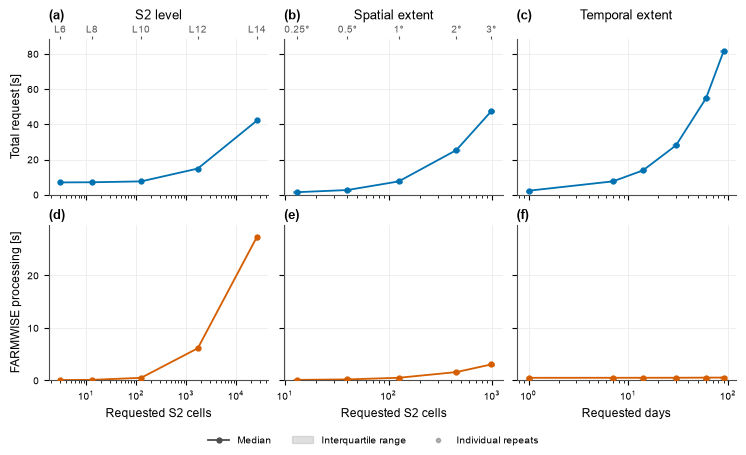

In [6]:
# Scaling runtime for the paper. Rows: total request time and FARMWISE's own
# processing (request time minus adapter time), each on its own linear axis.
# Columns: sweeps, against their actual workload. Median, IQR band, repeats.
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd

# Figure style shared by the paper figures. Applied locally, on top of
# matplotlib's defaults, so seaborn themes or dark notebook themes set
# elsewhere cannot leak into the saved figures.
PAPER_STYLE = {
    "font.size": 8.5, "axes.titlesize": 9, "axes.labelsize": 8.5,
    "xtick.labelsize": 7.5, "ytick.labelsize": 7.5, "legend.fontsize": 7.5,
    "legend.title_fontsize": 8, "axes.grid": True, "grid.color": "0.92",
    "grid.linewidth": 0.6, "axes.edgecolor": "0.3", "axes.spines.top": False,
    "axes.spines.right": False, "savefig.dpi": 300, "figure.facecolor": "white",
    "axes.facecolor": "white", "savefig.facecolor": "white",
}

# How each sweep is placed on the x-axis: the actual workload, not the nominal
# scenario value. The nominal value is kept as a secondary tick label.
SCALING_AXES = {
    "S2 level": ("requested_s2_cells", "Requested S2 cells", lambda v: f"L{v:g}"),
    "Spatial extent": ("requested_s2_cells", "Requested S2 cells", lambda v: f"{v:g}°"),
    "Temporal extent": ("duration_days", "Requested days", None),
}


def scaling_frame(runs: pd.DataFrame, dispatch: pd.DataFrame) -> pd.DataFrame:
    """Successful scaling runs with FARMWISE-internal time separated out.

    Adapters are awaited one after another, so request time minus the summed
    adapter wall times is the time FARMWISE spends outside the adapters:
    pre-check, harmonisation, aggregation and assembling the result.
    """
    scaling = runs[runs["experiment"] == "scaling"]
    failed = dispatch[(dispatch["experiment"] == "scaling") & (dispatch["status"] != "success")]
    if len(failed):
        summary = failed.groupby(["source_short", "status"]).size().to_dict()
        print(f"WARNING: {len(failed)} adapter calls in scaling runs did not succeed: {summary}.")
    frame = scaling[scaling["status"] == "success"].copy()
    frame["internal_seconds"] = (frame["request_wall_seconds"] - frame["dispatch_seconds_sum"]).clip(lower=0)
    return frame


def _band(ax, frame, x_column, value, colour, label):
    grouped = frame.groupby("input_value")
    stats = grouped.agg(x=(x_column, "median"), median=(value, "median"),
                        q1=(value, lambda s: s.quantile(0.25)),
                        q3=(value, lambda s: s.quantile(0.75))).sort_values("x")
    jitter = np.random.default_rng(0).uniform(0.94, 1.06, len(frame))
    ax.scatter(frame[x_column] * jitter, frame[value], s=5, color=colour, alpha=0.25,
               linewidths=0, zorder=2, rasterized=True)
    ax.fill_between(stats["x"], stats["q1"], stats["q3"], color=colour, alpha=0.18,
                    linewidth=0, zorder=1)
    ax.plot(stats["x"], stats["median"], color=colour, marker="o", markersize=3.5,
            linewidth=1.3, zorder=3, label=label)
    return stats


def _nominal_ticks(ax, stats, formatter):
    """Label the nominal scenario value (e.g. S2 level) along the top edge."""
    if formatter is None:
        return
    top = ax.secondary_xaxis("top")
    top.set_xticks(stats["x"].to_numpy(), labels=[formatter(v) for v in stats.index])
    top.xaxis.set_minor_locator(plt.NullLocator())
    top.tick_params(length=2, labelsize=7, colors="0.35", pad=1)
    top.spines["top"].set_visible(False)


def plot_scaling(frame: pd.DataFrame, series, *, path_stem=None):
    """One row per quantity, one column per sweep.

    ``series`` is a list of (column, colour, row label). Each row has its own
    linear y-axis from zero, shared across the sweeps in that row, so the IQR
    bands of quantities on very different scales (seconds of upstream wait vs
    tenths of a second of processing) all stay visible and comparable.
    """
    dimensions = [d for d in SCALING_AXES if d in set(frame["dimension"])]
    with plt.style.context("default"), plt.rc_context(PAPER_STYLE):
        fig, axes = plt.subplots(len(series), len(dimensions),
                                 figsize=(2.45 * len(dimensions), 2.05 * len(series) + 0.35),
                                 squeeze=False, sharex="col", sharey="row",
                                 constrained_layout=True)
        letters = iter("abcdefghijklmnop")
        for row, (column, colour, row_label) in enumerate(series):
            for col, dimension in enumerate(dimensions):
                ax = axes[row, col]
                x_column, x_label, formatter = SCALING_AXES[dimension]
                sub = frame[frame["dimension"] == dimension]
                stats = _band(ax, sub, x_column, column, colour, row_label)
                ax.set_xscale("log")
                # Only decade labels: minor log labels collide on short ranges.
                ax.xaxis.set_minor_formatter(plt.NullFormatter())
                ax.set_ylim(bottom=0, top=float(sub[column].max()) * 1.08)
                # Panel letter as a left-aligned title, so it never covers data;
                # every top-row title uses the same padding so they line up.
                pad = 14 if row == 0 else 4
                ax.set_title(f"({next(letters)})", loc="left", pad=pad, fontweight="bold")
                if row == 0:
                    ax.set_title(dimension, loc="center", pad=pad)
                    _nominal_ticks(ax, stats, formatter)
                if row == len(series) - 1:
                    ax.set_xlabel(x_label)
                if col == 0:
                    ax.set_ylabel(row_label)
            # sharey="row" keeps the largest limit only if every panel agrees.
            top = max(float(frame[column].max()) * 1.08, 1e-9)
            for ax in axes[row]:
                ax.set_ylim(0, top)
        handles = [
            Line2D([], [], color="0.3", marker="o", markersize=3.5, linewidth=1.3, label="Median"),
            Patch(color="0.6", alpha=0.3, label="Interquartile range"),
            Line2D([], [], color="0.3", marker="o", linestyle="", markersize=3, alpha=0.4,
                   label="Individual repeats"),
        ]
        fig.legend(handles=handles, loc="outside lower center", ncols=len(handles), frameon=False)
        if path_stem is not None:
            for suffix in (".pdf", ".png"):
                fig.savefig(Path(str(path_stem) + suffix), bbox_inches="tight")
    return fig


scaling_runs = scaling_frame(runs_df, dispatch_df)
fig = plot_scaling(
    scaling_runs,
    [("request_wall_seconds", "#0072B2", "Total request [s]"),
     ("internal_seconds", "#D55E00", "FARMWISE processing [s]")],
    path_stem=FIGURES / "scaling_runtime",
)
plt.show()


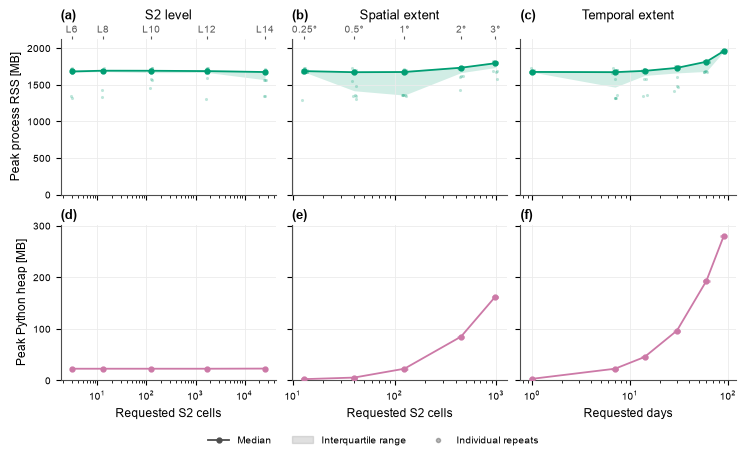

In [7]:
# Scaling memory for the paper. Rows: peak process RSS (primary metric) and the
# peak Python heap from tracemalloc. Uses the helpers and `scaling_runs` defined
# in the runtime cell above.
fig = plot_scaling(
    scaling_runs,
    [("peak_rss_mb", "#009E73", "Peak process RSS [MB]"),
     ("peak_traced_memory_mb", "#CC79A7", "Peak Python heap [MB]")],
    path_stem=FIGURES / "scaling_memory",
)
plt.show()


In [8]:
# Adapter/source timings within the scaling sweeps.
analysis.robust_summary(
    dispatch_df[dispatch_df["experiment"] == "scaling"],
    ["source_short", "dimension", "input_value"],
    "wall_seconds",
)

,source_short,dimension,input_value,n,median,q1,q3,iqr,median_ci_low,median_ci_high,min,max,mean,std
0,irish_ms_daily,S2 level,6.00,15,6.903909,6.891796,6.924914,0.033118,6.889002,6.927882,6.803203,6.959895,6.899459,0.046802
1,irish_ms_daily,S2 level,8.00,15,6.939836,6.912691,6.985046,0.072354,6.907154,6.983672,6.854040,7.032754,6.941848,0.058550
2,irish_ms_daily,S2 level,10.00,15,7.069801,7.050090,7.092025,0.041935,7.058709,7.098007,6.965095,7.111362,7.060468,0.043315
3,irish_ms_daily,S2 level,12.00,15,8.716895,8.685360,8.750794,0.065434,8.678763,8.731916,8.625160,8.828662,8.716961,0.054599
4,irish_ms_daily,S2 level,14.00,15,14.897109,14.854475,14.933019,0.078544,14.852328,14.934623,14.715407,15.019677,14.886252,0.077822
5,irish_ms_daily,Spatial extent,0.25,15,1.312781,1.303473,1.347164,0.043692,1.303051,1.349161,1.266503,1.424189,1.322614,0.041206
6,irish_ms_daily,Spatial extent,0.50,15,2.446263,2.419653,2.462581,0.042928,2.416798,2.462628,2.396592,2.504661,2.445937,0.032815
7,irish_ms_daily,Spatial extent,1.00,15,7.050658,7.007515,7.061860,0.054345,7.015845,7.064787,6.936334,7.148497,7.036563,0.050338
8,irish_ms_daily,Spatial extent,2.00,15,23.762345,23.747162,23.795628,0.048466,23.748781,23.805979,23.657541,23.900384,23.764721,0.072239
9,irish_ms_daily,Spatial extent,3.00,15,44.371076,44.307996,44.459248,0.151252,44.325088,44.486795,44.204922,44.608282,44.390623,0.128364


## 2. Quality-assessment overhead

One representative request (the scaling base case), 10 repeats each with
quality assessment off and on (assessment + persisted report, the server
default). The overhead is reported separately from the scaling results.

In [9]:
quality_cost = analysis.quality_overhead(runs_df)
pd.DataFrame({
    mode: quality_cost[f"runtime_{mode}"] for mode in ("off", "on")
}).T.assign(
    median_overhead_seconds=quality_cost["median_overhead_seconds"],
    overhead_ci_low=quality_cost["overhead_ci_low"],
    overhead_ci_high=quality_cost["overhead_ci_high"],
)

,n,median,q1,q3,iqr,median_ci_low,median_ci_high,min,max,mean,std,median_overhead_seconds,overhead_ci_low,overhead_ci_high
off,10.0,47.431974,47.230969,47.530037,0.299068,47.212865,47.642503,46.989330,47.863850,47.430106,0.278572,0.270103,0.04102,0.549521
on,10.0,47.702077,47.616045,47.805158,0.189114,47.592135,47.870765,47.416155,48.066052,47.734414,0.203063,0.270103,0.04102,0.549521


## 3. Coverage pre-check vs factor-only routing

Each coverage scenario runs with FARMWISE's registry-based pre-check and with a
factor-only baseline that dispatches every enabled source providing a requested
factor, ignoring spatial and temporal coverage. Disabled (e.g. licence-restricted)
sources are excluded in both modes. `requests_avoided_vs_factor_only` counts
adapter calls the pre-check saves; `unproductive_dispatches` are adapter calls
that ended empty, failed or timed out.

In [10]:
analysis.coverage_comparison(runs_df)

,scenario,mode,runs,planned_configured_sources,planned_factor_eligible_sources,planned_precheck_dispatched_sources,planned_requests_avoided_vs_factor_only,median_dispatched_sources,median_unproductive_dispatches,total_empty,...,runtime_median,runtime_q1,runtime_q3,runtime_iqr,runtime_median_ci_low,runtime_median_ci_high,runtime_min,runtime_max,runtime_mean,runtime_std
0,austria-meteo-overlap,factor-only,10,18,5,2,3,5.0,3.0,10,...,7.112237,6.897232,7.961257,1.064026,6.651932,8.555699,5.732757,9.822639,7.517494,1.338695
1,austria-meteo-overlap,precheck,10,18,5,2,3,2.0,0.0,0,...,4.718718,3.879939,6.245797,2.365858,3.859601,6.725924,3.713877,16.018537,6.071972,3.760310
2,germany-land-cover,factor-only,10,18,2,2,0,2.0,0.0,0,...,95.806184,94.659613,96.843639,2.184025,94.433609,97.055588,93.379797,100.359612,96.049974,1.991174
3,germany-land-cover,precheck,10,18,2,2,0,2.0,0.0,0,...,94.328894,93.961361,95.403003,1.441642,93.889093,96.440662,92.835995,157.104335,100.932553,19.797291
4,germany-meteo-overlap,factor-only,10,18,5,2,3,5.0,3.0,10,...,12.748982,11.475476,14.479382,3.003906,11.365554,14.586417,11.039044,15.348591,12.942790,1.719320
5,germany-meteo-overlap,precheck,10,18,5,2,3,2.0,0.0,0,...,11.076142,10.363849,12.514056,2.150207,10.312958,12.560084,10.014099,14.023093,11.478157,1.333547
6,germany-soil,factor-only,10,18,2,1,1,2.0,1.0,0,...,25.856464,22.096968,34.875007,12.778038,21.835799,36.380911,19.846792,43.471250,28.743418,8.715245
7,germany-soil,precheck,10,18,2,1,1,1.0,0.0,0,...,27.233912,20.375082,31.733214,11.358132,19.182313,35.649334,18.026298,51.258167,28.920475,10.422290
8,ireland-groundwater,factor-only,10,18,3,1,2,3.0,2.0,10,...,21.954866,21.927809,21.985564,0.057755,21.922981,22.007370,21.900303,23.607295,22.119027,0.524338
9,ireland-groundwater,precheck,10,18,3,1,2,1.0,0.0,0,...,0.703190,0.698635,0.711562,0.012927,0.692302,0.718621,0.683588,0.734064,0.705525,0.016203


In [11]:
precheck_saved = analysis.coverage_effect(runs_df)
precheck_saved.columns

Index(['scenario', 'n_precheck', 'n_factor_only', 'median_runtime_precheck',
       'median_runtime_factor_only', 'median_runtime_saved', 'saved_ci_low',
       'saved_ci_high', 'median_precheck_seconds',
       'requests_avoided_vs_factor_only'],
      dtype='str')

In [12]:
numeric = precheck_saved.select_dtypes(include="number")

summary = pd.DataFrame({
    "median": numeric.median(),
    "q1": numeric.quantile(0.25),
    "q3": numeric.quantile(0.75),
})

summary["iqr"] = summary["q3"] - summary["q1"]
summary

,median,q1,q3,iqr
n_precheck,10.000000,10.000000,10.000000,0.000000
n_factor_only,10.000000,10.000000,10.000000,0.000000
median_runtime_precheck,7.897430,0.541498,15.436605,14.895107
median_runtime_factor_only,21.705013,12.422784,28.465501,16.042717
median_runtime_saved,2.033180,1.092972,21.288442,20.195470
saved_ci_low,-0.246959,-0.978826,21.258157,22.236982
saved_ci_high,7.706254,3.576666,21.326659,17.749992
median_precheck_seconds,0.000451,0.000447,0.000452,0.000005
requests_avoided_vs_factor_only,3.000000,1.750000,3.000000,1.250000


In [13]:
# Pre-check overhead relative to the whole request (pre-check mode only).
precheck_runs = runs_df[(runs_df["experiment"] == "coverage") & (runs_df["mode"] == "precheck")].copy()
precheck_runs["precheck_share_pct"] = 100 * precheck_runs["precheck_seconds"] / precheck_runs["request_wall_seconds"]
pd.DataFrame({
    "precheck_microseconds": analysis.robust_stats(1e6 * precheck_runs["precheck_seconds"]),
    "precheck_share_of_request_pct": analysis.robust_stats(precheck_runs["precheck_share_pct"]),
}).T

,n,median,q1,q3,iqr,median_ci_low,median_ci_high,min,max,mean,std
precheck_microseconds,80.0,449.800000,443.95000,456.375000,12.425000,447.400000,451.500000,425.100000,542.300000,453.186250,20.424363
precheck_share_of_request_pct,80.0,0.005005,0.00285,0.239662,0.236812,0.003956,0.011652,0.000281,0.901717,0.210752,0.344019


## 3a. Share of runtime saved by the pre-check

Two complementary measures per coverage scenario:

* **Runtime saved** - `1 - median(pre-check) / median(factor-only)` of the whole
  request. It is what a user experiences, but it includes upstream noise (CDS
  queueing in ERA5 scenarios can exceed the effect itself). The bootstrap CI and
  the count of faster pairs (out of all pre-check x factor-only run pairs) show how
  stable the difference is; with 3 repeats per mode both are coarse.
* **Avoided adapter time** - median wall time, in factor-only mode, of the adapter
  calls the pre-check skips, as a share of the median factor-only request. It is
  attributable directly to the skipped calls and is far less sensitive to noise in
  the calls both modes make.

The pooled row sums the scenario medians, i.e. the saving over running the
whole scenario set once.

In [14]:
coverage = runs_df[runs_df["experiment"] == "coverage"]
rows = []
for scenario, group in coverage.groupby("scenario"):
    pre = group.loc[group["mode"] == "precheck", "request_wall_seconds"].dropna().to_numpy()
    base = group.loc[group["mode"] == "factor-only", "request_wall_seconds"].dropna().to_numpy()
    if len(pre) == 0 or len(base) == 0:
        continue
    ratios = (pre[:, None] / base[None, :]).ravel()   # every pre-check x factor-only pair
    rows.append({
        "scenario": scenario,
        "n_pre": len(pre), "n_base": len(base),
        "median_precheck_s": np.median(pre),
        "median_factor_only_s": np.median(base),
        "saved_pct": 100 * (1 - np.median(pre) / np.median(base)),
        "saved_pct_q1": 100 * (1 - np.quantile(ratios, 0.75)),  # note: quantiles swap
        "saved_pct_q3": 100 * (1 - np.quantile(ratios, 0.25)),
    })

timings = pd.DataFrame(rows)
typical = timings["saved_pct"].median()                    # typical scenario: 47.8 %
pooled = 100 * (1 - timings["median_precheck_s"].sum()
                / timings["median_factor_only_s"].sum())   # whole set once: 40.9 %
timings

,scenario,n_pre,n_base,median_precheck_s,median_factor_only_s,saved_pct,saved_pct_q1,saved_pct_q3
0,austria-meteo-overlap,10,10,4.718718,7.112237,33.653530,11.711793,46.153059
1,germany-land-cover,10,10,94.328894,95.806184,1.541956,-0.885653,2.700868
2,germany-meteo-overlap,10,10,11.076142,12.748982,13.121363,1.516631,23.078579
3,germany-soil,10,10,27.233912,25.856464,-5.327284,-31.337245,26.533044
4,ireland-groundwater,10,10,0.703190,21.954866,96.797111,96.756624,96.879144
5,ireland-precipitation-overlap,10,10,11.504170,11.444191,-0.524100,-7.739758,19.734038
6,no-spatial-coverage,10,10,0.056421,21.455160,99.737026,99.730258,99.742368
7,no-temporal-coverage,10,10,0.055924,36.292613,99.845908,99.818485,99.858401


## 4. Cross-source agreement

National sources against ERA5 in four regions and four seasonal months
(January, April, July, October 2018). Values are paired strictly on
scenario, timestamp, S2 cell and variable; differences are `national - ERA5`.
Daily precipitation totals from national services and ERA5 may use different
daily accumulation windows; this is not corrected and contributes to the
disagreement reported here.

In [15]:
observations = collection["observations"]
pairs = analysis.pair_observations(observations)
print("Paired observations:", len(pairs))
pairs.groupby(["region", "period", "variable", "source_pair"]).size().unstack("period")

Paired observations: 7375


period                                                  April  January  July  \
region                variable      source_pair                                
austria-meteo         precipitation GeoSphere - ERA5      300      310   310   
                      temperature   GeoSphere - ERA5      300      310   310   
germany-meteo         precipitation DWD - ERA5            210      217   217   
                      temperature   DWD - ERA5            210      217   217   
ireland-precipitation precipitation Met Éireann - ERA5    360      372   372   
poland-imgw-era5      precipitation IMGW - ERA5           210      217   217   
                      temperature   IMGW - ERA5           208      217   214   

period                                                  October  
region                variable      source_pair                  
austria-meteo         precipitation GeoSphere - ERA5        310  
                      temperature   GeoSphere - ERA5        310  
germany-meteo         precipitation DWD - ERA5              217  
                      temperature   DWD - ERA5              217  
ireland-precipitation precipitation Met Éireann - ERA5      372  
poland-imgw-era5      precipitation IMGW - ERA5             217  
                      temperature   IMGW - ERA5             217

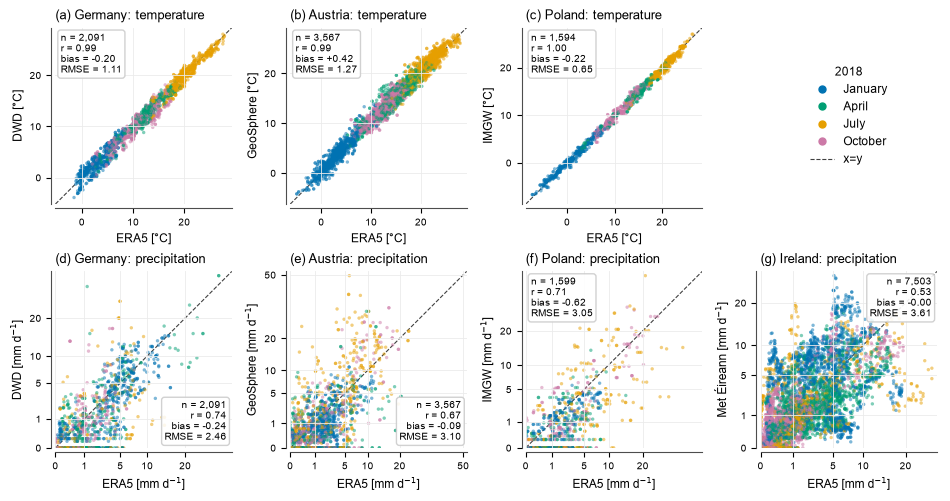

In [16]:
# Cross-source agreement scatter plots for the paper: one panel per region and
# variable, national source (y) against ERA5 (x), coloured by season, with the
# same agreement statistics as analysis.agreement_metrics. Precipitation uses
# square-root axes because daily totals are concentrated near zero.
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd

REFERENCE = "ERA5"
KEY = ["scenario", "region", "period", "timestamp", "cell", "variable"]
REGION_ORDER = ["germany-meteo", "austria-meteo", "poland-imgw-era5", "ireland-precipitation"]
REGION_LABELS = {
    "germany-meteo": "Germany",
    "austria-meteo": "Austria",
    "poland-imgw-era5": "Poland",
    "ireland-precipitation": "Ireland",
}
VARIABLES = {"temperature": ("Daily mean temperature", "°C"),
             "precipitation": ("Daily precipitation", "mm d$^{-1}$")}
PERIOD_ORDER = ["January", "April", "July", "October"]
# Okabe-Ito colours: distinguishable with colour-vision deficiency and in greyscale.
PERIOD_COLOURS = {"January": "#0072B2", "April": "#009E73", "July": "#E69F00", "October": "#CC79A7"}


def pair_with_reference(observations: pd.DataFrame, reference: str = REFERENCE) -> pd.DataFrame:
    """Pair each non-reference source with the reference on identical keys.

    One vectorised merge instead of a Python loop over every key: the result
    matches ``analysis.pair_observations`` for national-vs-ERA5 pairs.
    """
    obs = observations.assign(value=pd.to_numeric(observations["value"], errors="coerce"))
    obs = obs.dropna(subset=["value"])
    # One value per source and key, as in analysis.pair_observations.
    obs = obs.groupby(KEY + ["source"], dropna=False, as_index=False)["value"].mean()
    ref = obs[obs["source"] == reference].drop(columns="source").rename(columns={"value": "value_b"})
    other = obs[obs["source"] != reference].rename(columns={"source": "source_a", "value": "value_a"})
    pairs = other.merge(ref, on=KEY, how="inner")
    pairs["source_b"] = reference
    pairs["source_pair"] = pairs["source_a"] + " - " + reference
    pairs["difference"] = pairs["value_a"] - pairs["value_b"]
    return pairs


SQRT_VARIABLES = {"precipitation"}  # zero-heavy: square-root axes spread the bulk near 0
SQRT_TICKS = [0, 1, 5, 10, 20, 50, 100]


def _sqrt(values):
    return np.sqrt(np.clip(values, 0, None))


def _sqrt_axes(ax, high):
    ax.set_xscale("function", functions=(_sqrt, np.square))
    ax.set_yscale("function", functions=(_sqrt, np.square))
    # Locators must be set after the scale: set_*scale resets them.
    ticks = [t for t in SQRT_TICKS if t <= high]
    for axis in (ax.xaxis, ax.yaxis):
        axis.set_major_locator(plt.FixedLocator(ticks))
        axis.set_major_formatter(plt.FuncFormatter(lambda v, _pos: f"{v:g}"))


def _emptiest_corner(x, y, limits, sqrt):
    """Corner of the panel (in drawn coordinates) holding the fewest points."""
    transform = _sqrt if sqrt else (lambda v: np.asarray(v, dtype=float))
    lo, hi = transform(limits[0]), transform(limits[1])
    u = (transform(x) - lo) / (hi - lo)
    v = (transform(y) - lo) / (hi - lo)
    size = 0.42
    corners = {
        ("left", "top"): (u < size) & (v > 1 - size),
        ("right", "top"): (u > 1 - size) & (v > 1 - size),
        ("right", "bottom"): (u > 1 - size) & (v < size),
        ("left", "bottom"): (u < size) & (v < size),
    }
    return min(corners, key=lambda corner: int(np.sum(corners[corner])))


def _panel(ax, sub, variable, unit):
    national = sub["source_a"].iloc[0]
    # One scatter in a fixed random order, so no season is systematically
    # drawn on top of the others.
    order = np.random.default_rng(0).permutation(len(sub))
    shuffled = sub.iloc[order]
    ax.scatter(shuffled["value_b"], shuffled["value_a"], s=6, alpha=0.5, linewidths=0,
               c=shuffled["period"].map(PERIOD_COLOURS), rasterized=True)
    low = min(sub["value_a"].min(), sub["value_b"].min())
    high = max(sub["value_a"].max(), sub["value_b"].max())
    if variable in SQRT_VARIABLES:
        limits = (0.0, high * 1.05)
        _sqrt_axes(ax, limits[1])
        diagonal = np.linspace(*limits, 200)
    else:
        pad = 0.04 * (high - low)
        limits = (low - pad, high + pad)
        diagonal = np.array(limits)
    ax.plot(diagonal, diagonal, color="0.25", linewidth=0.8, linestyle="--", zorder=0)
    ax.set_xlim(limits)
    ax.set_ylim(limits)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(f"{REFERENCE} [{unit}]")
    ax.set_ylabel(f"{national} [{unit}]")

    m = analysis.agreement_metrics(sub, by=["variable"]).iloc[0]
    text = (f"n = {m['n_pairs']:,}\n"
            f"r = {m['pearson_r']:.2f}\n"
            f"bias = {m['mean_bias']:+.2f}\n"
            f"RMSE = {m['rmse']:.2f}")
    ha, va = _emptiest_corner(sub["value_b"], sub["value_a"], limits,
                              sqrt=variable in SQRT_VARIABLES)
    x = 0.03 if ha == "left" else 0.97
    y = 0.97 if va == "top" else 0.03
    # Offset the axis lines so values of exactly zero stay visible.
    for side in ("left", "bottom"):
        ax.spines[side].set_position(("outward", 3))
    ax.text(x, y, text, transform=ax.transAxes, ha=ha, va=va, fontsize=7,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.8", alpha=0.9))


def plot_cross_source_scatter(pairs: pd.DataFrame, path_stem=None):
    variables = [v for v in VARIABLES if v in set(pairs["variable"])]
    regions = [r for r in REGION_ORDER if r in set(pairs["region"])]
    style = {"font.size": 8.5, "axes.titlesize": 9, "axes.labelsize": 8.5,
             "xtick.labelsize": 7.5, "ytick.labelsize": 7.5, "axes.grid": True,
             "grid.color": "0.92", "grid.linewidth": 0.6, "axes.edgecolor": "0.3",
             "axes.spines.top": False, "axes.spines.right": False, "savefig.dpi": 300}
    with plt.style.context("default"), plt.rc_context(style):
        fig, axes = plt.subplots(len(variables), len(regions),
                                 figsize=(2.35 * len(regions), 2.45 * len(variables)),
                                 squeeze=False, constrained_layout=True)
        letters = iter("abcdefghijklmnop")
        empty = []
        for row, variable in enumerate(variables):
            label, unit = VARIABLES[variable]
            for col, region in enumerate(regions):
                ax = axes[row, col]
                sub = pairs[(pairs["variable"] == variable) & (pairs["region"] == region)]
                if sub.empty:
                    ax.set_axis_off()
                    empty.append(ax)
                    continue
                _panel(ax, sub, variable, unit)
                ax.set_title(f"({next(letters)}) {REGION_LABELS.get(region, region)}: "
                             f"{label.split()[-1].lower()}", loc="left")
        handles = [Line2D([], [], marker="o", linestyle="", markersize=5, color=c, label=p)
                   for p, c in PERIOD_COLOURS.items()]
        handles.append(Line2D([], [], color="0.25", linestyle="--", linewidth=0.8, label="x=y"))
        if empty:
            empty[0].legend(handles=handles, title="2018", loc="center", frameon=False)
        else:
            fig.legend(handles=handles, title="2018", loc="outside right center", frameon=False)
        if path_stem is not None:
            for suffix in (".pdf", ".png"):
                fig.savefig(Path(str(path_stem) + suffix), bbox_inches="tight", dpi=300)
    return fig

scatter_pairs = pair_with_reference(observations)
fig = plot_cross_source_scatter(scatter_pairs, FIGURES / "cross_source_scatter")
plt.show()


In [17]:
agreement_by_season = analysis.agreement_metrics(
    pairs, by=["region", "variable", "source_pair", "period"]
)
agreement_by_season

,region,variable,source_pair,period,n_pairs,n_cells,mean_bias,median_bias,mae,rmse,pearson_r,spearman_rho
0,austria-meteo,precipitation,GeoSphere - ERA5,April,300,10,-0.258888,-0.001907,1.009363,2.753338,0.508618,0.547978
1,austria-meteo,precipitation,GeoSphere - ERA5,January,310,10,-0.619308,-0.170167,1.063742,1.692724,0.664351,0.704681
2,austria-meteo,precipitation,GeoSphere - ERA5,July,310,10,0.646291,-0.050584,1.948235,4.488434,0.694399,0.735371
3,austria-meteo,precipitation,GeoSphere - ERA5,October,310,10,-0.074642,-0.002861,0.957306,2.388390,0.821464,0.622771
4,austria-meteo,temperature,GeoSphere - ERA5,April,300,10,0.153603,0.108625,0.858312,1.109232,0.953274,0.942428
5,austria-meteo,temperature,GeoSphere - ERA5,January,310,10,0.308300,0.213232,0.691220,0.906531,0.952780,0.943702
6,austria-meteo,temperature,GeoSphere - ERA5,July,310,10,0.160510,0.258156,0.844097,1.057064,0.935351,0.921167
7,austria-meteo,temperature,GeoSphere - ERA5,October,310,10,0.390812,0.420421,0.774064,0.956459,0.943152,0.945926
8,germany-meteo,precipitation,DWD - ERA5,April,210,7,-0.387675,-0.002282,1.055459,2.098904,0.869441,0.734220
9,germany-meteo,precipitation,DWD - ERA5,January,217,7,-0.527920,-0.204663,1.528228,2.294210,0.808955,0.827925


In [18]:
agreement_pooled = analysis.agreement_metrics(pairs, by=["region", "variable", "source_pair"])
agreement_pooled

,region,variable,source_pair,n_pairs,n_cells,mean_bias,median_bias,mae,rmse,pearson_r,spearman_rho
0,austria-meteo,precipitation,GeoSphere - ERA5,1230,10,-0.075155,-0.029676,1.246575,3.014349,0.684307,0.680616
1,austria-meteo,temperature,GeoSphere - ERA5,1230,10,0.254117,0.235597,0.791384,1.009652,0.990607,0.988807
2,germany-meteo,precipitation,DWD - ERA5,861,7,-0.261596,-0.010490,1.076667,2.341060,0.751396,0.788015
3,germany-meteo,temperature,DWD - ERA5,861,7,-0.105871,-0.035139,0.735994,0.960545,0.990438,0.989287
4,ireland-precipitation,precipitation,Met Éireann - ERA5,1476,12,-0.050286,-0.061163,2.013989,3.571046,0.537160,0.727332
5,poland-imgw-era5,precipitation,IMGW - ERA5,861,7,-0.555205,-0.065962,1.404540,3.249104,0.706313,0.732111
6,poland-imgw-era5,temperature,IMGW - ERA5,856,7,-0.216024,-0.151819,0.494862,0.651710,0.996840,0.996191


In [19]:
precipitation = analysis.precipitation_agreement(pairs, by=["region", "source_pair", "period"])
precipitation

,region,source_pair,period,n_pairs,wet_threshold_mm,both_wet,wet_only_a,wet_only_b,both_dry,wet_day_agreement,wet_day_kappa,total_a_mm,total_b_mm,median_cell_accumulation_difference_mm,median_cell_relative_accumulation_difference,cells
0,austria-meteo,GeoSphere - ERA5,April,300,1.0,29,13,36,222,0.836667,0.448198,230.231667,307.898124,-8.791087,-0.344343,10
1,austria-meteo,GeoSphere - ERA5,January,310,1.0,72,10,76,152,0.722581,0.433104,305.595000,497.580528,-20.903490,-0.412002,10
2,austria-meteo,GeoSphere - ERA5,July,310,1.0,73,17,39,181,0.819355,0.591145,866.695833,666.345676,17.559999,0.229451,10
3,austria-meteo,GeoSphere - ERA5,October,310,1.0,39,6,46,219,0.832258,0.506279,359.730833,382.869959,-3.007728,-0.089403,10
4,germany-meteo,DWD - ERA5,April,210,1.0,40,14,35,121,0.766667,0.458136,321.166667,402.578511,-12.579568,-0.203148,7
5,germany-meteo,DWD - ERA5,January,217,1.0,106,1,32,78,0.847926,0.696991,664.300000,778.858542,-18.678701,-0.178100,7
6,germany-meteo,DWD - ERA5,July,217,1.0,28,7,16,166,0.894009,0.645097,198.383333,236.841520,-9.115366,-0.238245,7
7,germany-meteo,DWD - ERA5,October,217,1.0,29,9,20,159,0.866359,0.584758,148.700000,139.505227,-4.785569,-0.226423,7
8,ireland-precipitation,Met Éireann - ERA5,April,360,1.0,165,31,54,110,0.763889,0.518505,787.536317,1089.887896,-28.785143,-0.307509,12
9,ireland-precipitation,Met Éireann - ERA5,January,372,1.0,215,43,54,60,0.739247,0.369602,1829.952331,1452.690819,31.113889,0.247132,12


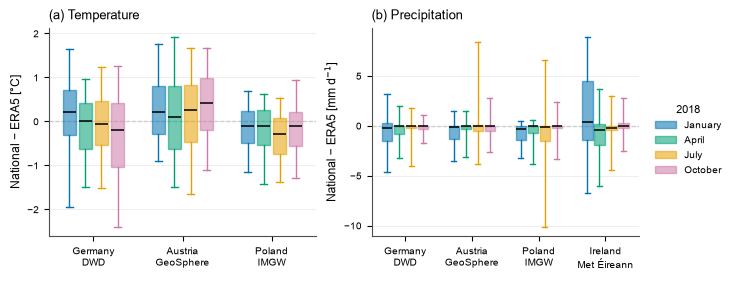

In [20]:
# National minus ERA5 differences per region and season for the paper. Boxes:
# IQR with median; whiskers: 5th-95th percentiles; values beyond are not drawn.
# Uses `pairs` from the pairing cell and PAPER_STYLE from the scaling cell.
DIFF_REGION_ORDER = ["germany-meteo", "austria-meteo", "poland-imgw-era5", "ireland-precipitation"]
DIFF_REGION_LABELS = {"germany-meteo": "Germany\nDWD", "austria-meteo": "Austria\nGeoSphere",
                      "poland-imgw-era5": "Poland\nIMGW", "ireland-precipitation": "Ireland\nMet Éireann"}
DIFF_VARIABLES = {"temperature": ("Temperature", "°C"), "precipitation": ("Precipitation", "mm d$^{-1}$")}
DIFF_PERIODS = ["January", "April", "July", "October"]
DIFF_COLOURS = {"January": "#0072B2", "April": "#009E73", "July": "#E69F00", "October": "#CC79A7"}


def plot_difference_boxes(pairs: pd.DataFrame, path_stem=None):
    """National minus ERA5 differences per region, one box per season.

    Boxes span the interquartile range with the median marked; whiskers reach
    the 5th and 95th percentiles; values beyond them are not drawn.
    """
    variables = [v for v in DIFF_VARIABLES if v in set(pairs["variable"])]
    with plt.style.context("default"), plt.rc_context(PAPER_STYLE):
        fig, axes = plt.subplots(1, len(variables), figsize=(3.6 * len(variables), 2.7),
                                 squeeze=False, constrained_layout=True)
        width = 0.18
        for letter, ax, variable in zip("abcdefgh", axes[0], variables):
            label, unit = DIFF_VARIABLES[variable]
            sub = pairs[pairs["variable"] == variable]
            regions = [r for r in DIFF_REGION_ORDER if r in set(sub["region"])]
            for i, region in enumerate(regions):
                for j, period in enumerate(DIFF_PERIODS):
                    values = sub.loc[(sub["region"] == region) & (sub["period"] == period),
                                     "difference"].dropna()
                    if values.empty:
                        continue
                    position = i + (j - (len(DIFF_PERIODS) - 1) / 2) * width
                    colour = DIFF_COLOURS[period]
                    ax.boxplot(values, positions=[position], widths=width * 0.85,
                               whis=(5, 95), showfliers=False, patch_artist=True,
                               boxprops=dict(facecolor=colour, edgecolor=colour, alpha=0.55),
                               medianprops=dict(color="black", linewidth=1.1),
                               whiskerprops=dict(color=colour, linewidth=1),
                               capprops=dict(color=colour, linewidth=1))
            ax.axhline(0, color="0.25", linewidth=0.8, linestyle="--", zorder=0)
            ax.set_xticks(range(len(regions)), labels=[DIFF_REGION_LABELS.get(r, r) for r in regions])
            ax.set_xlim(-0.5, len(regions) - 0.5)
            ax.grid(axis="x", visible=False)
            ax.set_ylabel(f"National − ERA5 [{unit}]")
            ax.set_title(f"({letter}) {label}", loc="left")
        handles = [Patch(facecolor=c, edgecolor=c, alpha=0.55, label=p) for p, c in DIFF_COLOURS.items()]
        fig.legend(handles=handles, title="2018", loc="outside right center", frameon=False)
        if path_stem is not None:
            for suffix in (".pdf", ".png"):
                fig.savefig(Path(str(path_stem) + suffix), bbox_inches="tight")
    return fig


fig = plot_difference_boxes(pairs, FIGURES / "cross_source_differences")
plt.show()


## 4a. Is RMSE an adequate summary of cross-source disagreement?

RMSE decomposes as RMSE² = bias² + σ², where σ is the standard deviation of the
differences. It summarises disagreement well only when the differences are roughly
symmetric, light-tailed and of similar spread across conditions; otherwise a few
large differences dominate it. The table reports:

* `bias`, `sd` and `bias2_share` (bias² / RMSE²) - how much of the RMSE is a
  systematic offset rather than scatter;
* `mae`, `median_abs` - robust magnitudes; a median far below RMSE means RMSE is
  driven by the tail;
* `skewness`, `excess_kurtosis` (0 for a normal distribution);
* `top5_mse_share` - share of the squared error carried by the 5 % largest
  absolute differences. For normally distributed differences it is
  `normal_top5_mse_share` (about 0.28); much larger values mean RMSE mostly
  reflects a few extreme days.

In [21]:
from scipy import stats

z95 = stats.norm.ppf(0.975)
NORMAL_TOP5_MSE_SHARE = float(2 * (z95 * stats.norm.pdf(z95) + stats.norm.sf(z95)))


def error_distribution(pairs, by=("region", "variable", "source_pair")):
    """Distribution diagnostics of national - ERA5 differences."""
    rows = []
    for keys, group in pairs.groupby(list(by)):
        e = group["difference"].to_numpy(dtype=float)
        mse = float(np.mean(e ** 2))
        largest = np.sort(np.abs(e))[::-1][: max(1, int(round(0.05 * len(e))))]
        rows.append({
            **dict(zip(by, keys)),
            "n_pairs": len(e),
            "bias": float(np.mean(e)),
            "sd": float(np.std(e)),
            "rmse": float(np.sqrt(mse)),
            "bias2_share": float(np.mean(e) ** 2 / mse) if mse else np.nan,
            "mae": float(np.mean(np.abs(e))),
            "median_abs": float(np.median(np.abs(e))),
            "skewness": float(stats.skew(e)),
            "excess_kurtosis": float(stats.kurtosis(e)),
            "top5_mse_share": float(np.sum(largest ** 2) / np.sum(e ** 2)) if mse else np.nan,
            "normal_top5_mse_share": NORMAL_TOP5_MSE_SHARE,
        })
    return pd.DataFrame(rows)


error_shape = error_distribution(pairs)
error_shape.round(3)


,region,variable,source_pair,n_pairs,bias,sd,rmse,bias2_share,mae,median_abs,skewness,excess_kurtosis,top5_mse_share,normal_top5_mse_share
0,austria-meteo,precipitation,GeoSphere - ERA5,1230,-0.075,3.013,3.014,0.001,1.247,0.203,3.487,30.563,0.810,0.279
1,austria-meteo,temperature,GeoSphere - ERA5,1230,0.254,0.977,1.010,0.063,0.791,0.662,0.120,0.713,0.326,0.279
2,germany-meteo,precipitation,DWD - ERA5,861,-0.262,2.326,2.341,0.012,1.077,0.239,1.510,20.291,0.716,0.279
3,germany-meteo,temperature,DWD - ERA5,861,-0.106,0.955,0.961,0.012,0.736,0.585,-0.513,0.427,0.319,0.279
4,ireland-precipitation,precipitation,Met Éireann - ERA5,1476,-0.050,3.571,3.571,0.000,2.014,0.668,-0.319,6.912,0.541,0.279
5,poland-imgw-era5,precipitation,IMGW - ERA5,861,-0.555,3.201,3.249,0.029,1.405,0.231,0.478,22.746,0.787,0.279
6,poland-imgw-era5,temperature,IMGW - ERA5,856,-0.216,0.615,0.652,0.110,0.495,0.375,-0.319,0.392,0.326,0.279


## 4b. Heteroscedasticity: does the magnitude of disagreement depend on value or season?

The dispersion of each difference is measured as its absolute deviation from the
group median, `|d - median(d)|` (the Brown-Forsythe / Glejser construction, robust
to heavy tails). Value is represented by the pair mean `(national + ERA5) / 2`, so
neither source is privileged and there is no regression-to-the-mean artefact.

* `spearman_rho_value`, `p_value_trend` - monotonic association between dispersion
  and value;
* `brown_forsythe_p` - equality of spread across seasons (Levene test with the
  median);
* `p_value_given_season`, `p_season_given_value` - partial F-tests from an OLS
  model of dispersion on value and season: does value still matter once season is
  accounted for, and vice versa? Value and season are confounded (heavy rain in
  July, cold days in January), so these are the tests that separate them.

Pairs are not independent: several S2 cells share a day, and consecutive days are
correlated, which makes p-values optimistic. The `daily_*` columns repeat the value
and season tests on per-day means of dispersion and value as a conservative check.

For precipitation both values are non-negative, so `|national - ERA5|` can never
exceed twice the pair mean (the straight upper edge in the figure below). Spread
growing with intensity is therefore partly guaranteed by construction; relative or
log-ratio errors on wet days describe precipitation disagreement more fairly than
absolute errors.

In [22]:
def _ols_rss(y, X):
    beta, *_ = np.linalg.lstsq(X, y, rcond=None)
    return float(np.sum((y - X @ beta) ** 2)), X.shape[1]


def _partial_f(y, X_reduced, X_full):
    rss_r, k_r = _ols_rss(y, X_reduced)
    rss_f, k_f = _ols_rss(y, X_full)
    df1, df2 = k_f - k_r, len(y) - k_f
    if df1 <= 0 or df2 <= 0 or rss_f == 0:
        return np.nan
    f = ((rss_r - rss_f) / df1) / (rss_f / df2)
    return float(stats.f.sf(f, df1, df2))


def _dispersion_tests(frame, value="pair_mean", dispersion="dispersion"):
    y = frame[dispersion].to_numpy(dtype=float)
    x = frame[value].to_numpy(dtype=float)
    seasons = pd.get_dummies(frame["period"], drop_first=True, dtype=float).to_numpy()
    ones = np.ones((len(y), 1))
    X_value, X_season = np.column_stack([ones, x]), np.column_stack([ones, seasons])
    X_full = np.column_stack([ones, x, seasons])
    groups = [g[dispersion].to_numpy() for _, g in frame.groupby("period") if len(g) > 1]
    rho, p_rho = stats.spearmanr(x, y) if np.ptp(x) > 0 else (np.nan, np.nan)
    return {
        "spearman_rho_value": float(rho),
        "p_value_trend": float(p_rho),
        "brown_forsythe_p": float(stats.levene(*groups, center="median").pvalue) if len(groups) > 1 else np.nan,
        "p_value_given_season": _partial_f(y, X_season, X_full) if seasons.size else np.nan,
        "p_season_given_value": _partial_f(y, X_value, X_full) if seasons.size else np.nan,
    }


def heteroscedasticity(pairs, by=("region", "variable", "source_pair")):
    data = pairs.assign(pair_mean=(pairs["value_a"] + pairs["value_b"]) / 2)
    rows = []
    for keys, group in data.groupby(list(by)):
        group = group.assign(dispersion=(group["difference"] - group["difference"].median()).abs())
        daily = (group.groupby(["timestamp", "period"], as_index=False)
                 .agg(pair_mean=("pair_mean", "mean"), dispersion=("dispersion", "mean")))
        full = _dispersion_tests(group)
        conservative = _dispersion_tests(daily)
        rows.append({
            **dict(zip(by, keys)),
            "n_pairs": len(group),
            "n_days": len(daily),
            **full,
            "daily_p_value_trend": conservative["p_value_trend"],
            "daily_brown_forsythe_p": conservative["brown_forsythe_p"],
            "daily_p_value_given_season": conservative["p_value_given_season"],
            "daily_p_season_given_value": conservative["p_season_given_value"],
        })
    return pd.DataFrame(rows)


error_heteroscedasticity = heteroscedasticity(pairs)
error_heteroscedasticity.round(4)


,region,variable,source_pair,n_pairs,n_days,spearman_rho_value,p_value_trend,brown_forsythe_p,p_value_given_season,p_season_given_value,daily_p_value_trend,daily_brown_forsythe_p,daily_p_value_given_season,daily_p_season_given_value
0,austria-meteo,precipitation,GeoSphere - ERA5,1230,123,0.8766,0.0000,0.0000,0.0000,0.2315,0.0000,0.1503,0.0000,0.6839
1,austria-meteo,temperature,GeoSphere - ERA5,1230,123,0.0849,0.0029,0.0009,0.7390,0.0126,0.0039,0.6537,0.7532,0.2453
2,germany-meteo,precipitation,DWD - ERA5,861,123,0.8911,0.0000,0.0047,0.0000,0.0020,0.0000,0.4868,0.0000,0.1926
3,germany-meteo,temperature,DWD - ERA5,861,123,-0.0749,0.0280,0.0000,0.8778,0.0004,0.0186,0.0002,0.1555,0.0000
4,ireland-precipitation,precipitation,Met Éireann - ERA5,1476,123,0.8514,0.0000,0.0000,0.0000,0.0000,0.0000,0.0067,0.0000,0.0975
5,poland-imgw-era5,precipitation,IMGW - ERA5,861,123,0.8143,0.0000,0.0000,0.0000,0.0000,0.0000,0.0013,0.0000,0.0124
6,poland-imgw-era5,temperature,IMGW - ERA5,856,123,0.0355,0.2999,0.2514,0.5805,0.5275,0.2537,0.9277,0.1552,0.5187


In [23]:
from pathlib import Path
import json

import numpy as np
import pandas as pd


# ============================================================
# CONFIG
# ============================================================

QUALITY_DIR = INPUT.parent / payload.get(
    "quality_report_dir",
    "quality",
)
OUT_DIR = Path("quality_summary")

OUT_DIR.mkdir(exist_ok=True)


# ============================================================
# HELPERS
# ============================================================

def load_quality_report(path: Path) -> dict:
    """
    Supports:
      - JSON quality reports
      - one-row CSV quality reports

    The attached example is JSON.
    """

    # First try JSON, regardless of extension
    try:
        with path.open("r", encoding="utf-8") as f:
            obj = json.load(f)

        if isinstance(obj, dict):
            return obj

    except (json.JSONDecodeError, UnicodeDecodeError):
        pass


def to_datetime(value):
    return pd.to_datetime(
        value,
        errors="coerce",
    )


def safe_div(a, b):
    if pd.isna(a) or pd.isna(b) or b == 0:
        return np.nan
    return a / b


def weighted_fraction(values, weights):
    """Weighted mean of report-level fractions, bounded to [0, 1]."""
    values = pd.to_numeric(values, errors="coerce").clip(0, 1)
    weights = pd.to_numeric(weights, errors="coerce")
    valid = values.notna() & weights.notna() & (weights > 0)
    if not valid.any():
        return np.nan
    return float(np.average(values[valid], weights=weights[valid]))


def p05(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    return x.quantile(0.05) if len(x) else np.nan


def p95(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    return x.quantile(0.95) if len(x) else np.nan


def cv_pct(x):
    x = pd.to_numeric(x, errors="coerce").dropna()

    if len(x) < 2 or x.mean() == 0:
        return np.nan

    return (
        100
        * x.std(ddof=1)
        / abs(x.mean())
    )


def summarise_group(group):
    """
    Summarise a set of quality reports.
    """

    result = {
        # number of reports
        "n_reports": len(group),

        # ----------------------------------------------------
        # S2 spatial support (descriptive, not a quality defect)
        # ----------------------------------------------------

        "S2_support_mean":
            group["S2_support_fraction"].mean(),

        "S2_support_median":
            group["S2_support_fraction"].median(),

        "S2_support_std":
            group["S2_support_fraction"].std(),

        "S2_support_p05":
            p05(group["S2_support_fraction"]),

        "S2_support_p95":
            p95(group["S2_support_fraction"]),

        "S2_support_min":
            group["S2_support_fraction"].min(),

        "S2_support_max":
            group["S2_support_fraction"].max(),

        # weighted by expected cells; uses the report-level intersection
        # fraction, so cells outside the request cannot push it above 1
        "S2_support_weighted":
            weighted_fraction(
                group["S2_support_fraction"],
                group["expected_s2_cells"],
            ),

        "expected_s2_cells_total":
            group["expected_s2_cells"].sum(),

        "returned_s2_cells_total":
            group["returned_s2_cells"].sum(),

        "unrepresented_s2_cells_total":
            group["unrepresented_s2_cells"].sum(),

        # ----------------------------------------------------
        # TEMPORAL COMPLETENESS
        # ----------------------------------------------------

        "missing_days_mean":
            group["missing_days"].mean(),

        "missing_days_median":
            group["missing_days"].median(),

        "missing_days_p95":
            p95(group["missing_days"]),

        "missing_days_max":
            group["missing_days"].max(),

        "reports_with_missing_days":
            (group["missing_days"] > 0).sum(),

        "reports_with_missing_days_pct":
            100 * (group["missing_days"] > 0).mean(),

        # independently derived from expected/returned
        # date boundaries
        "start_delay_days_mean":
            group["start_delay_days"].mean(),

        "end_cutshort_days_mean":
            group["end_cutshort_days"].mean(),

        "temporal_span_completeness_mean":
            group["temporal_span_completeness"].mean(),

        "temporal_span_completeness_min":
            group["temporal_span_completeness"].min(),

        # ----------------------------------------------------
        # MISSING VALUES
        # ----------------------------------------------------

        "total_missing_values_mean":
            group["total_missing_values"].mean(),

        "total_missing_values_median":
            group["total_missing_values"].median(),

        "total_missing_values_p95":
            p95(group["total_missing_values"]),

        "total_missing_values_max":
            group["total_missing_values"].max(),

        "reports_with_missing_values":
            (group["total_missing_values"] > 0).sum(),

        "reports_with_missing_values_pct":
            100
            * (group["total_missing_values"] > 0).mean(),

        "factor_missing_values_mean":
            group["factor_missing_values"].mean(),

        # ----------------------------------------------------
        # ERROR / IMPLAUSIBLE VALUES
        # ----------------------------------------------------

        "error_values_mean":
            group["error_values"].mean(),

        "error_values_median":
            group["error_values"].median(),

        "error_values_p95":
            p95(group["error_values"]),

        "error_values_max":
            group["error_values"].max(),

        "reports_with_error_values":
            (group["error_values"] > 0).sum(),

        "reports_with_error_values_pct":
            100
            * (group["error_values"] > 0).mean(),

        # ----------------------------------------------------
        # FACTOR COMPLETENESS
        # ----------------------------------------------------

        "factor_completeness_mean":
            group["factors_returned_completeness"].mean(),

        "factor_completeness_median":
            group["factors_returned_completeness"].median(),

        "factor_completeness_min":
            group["factors_returned_completeness"].min(),

        "factor_completeness_p05":
            p05(group["factors_returned_completeness"]),

        "supported_factors_total":
            group["supported_factor_count"].sum(),

        "returned_output_columns_total":
            group["returned_output_column_count"].sum(),

        # Completeness applies only to requested factors supported by this
        # source. A logical factor such as soil may yield many columns.
        "factor_completeness_weighted":
            weighted_fraction(
                group["factors_returned_completeness"],
                group["supported_factor_count"],
            ),

        "reports_with_incomplete_supported_factors":
            (
                group["factors_returned_completeness"] < 1
            ).sum(),

        "reports_with_incomplete_supported_factors_pct":
            100 * (
                group["factors_returned_completeness"] < 1
            ).mean(),
    }

    return pd.Series(result)


# ============================================================
# READ ALL FILES
# ============================================================

report_rows = []
factor_rows = []

files = [
    p
    for p in QUALITY_DIR.iterdir()
    if p.is_file()
]

print(
    f"Found {len(files):,} quality report files."
)


for path in files:

    try:
        report = load_quality_report(path)

    except Exception as e:
        print(
            f"SKIPPING {path.name}: {e}"
        )
        continue

    # --------------------------------------------------------
    # BASIC VALUES
    # --------------------------------------------------------

    source = report.get("source")

    # fallback to filename if source field is absent
    if not source:
        filename = path.stem

        if "_" in filename:
            source = filename.split(
                "_",
                maxsplit=1,
            )[1]

    level = pd.to_numeric(
        report.get("S2_level"),
        errors="coerce",
    )

    expected_s2 = pd.to_numeric(
        report.get("expected_s2_cells"),
        errors="coerce",
    )

    returned_s2 = pd.to_numeric(
        report.get("returned_s2_cells"),
        errors="coerce",
    )

    s2_support_fraction = pd.to_numeric(
        report.get("S2_completeness"),
        errors="coerce",
    )
    if pd.notna(s2_support_fraction):
        s2_support_fraction = float(
            np.clip(s2_support_fraction, 0, 1)
        )
    represented_s2 = (
        s2_support_fraction * expected_s2
        if pd.notna(s2_support_fraction) and pd.notna(expected_s2)
        else np.nan
    )

    # --------------------------------------------------------
    # DATES
    # --------------------------------------------------------

    expected_start = to_datetime(
        report.get("expected_start")
    )

    expected_end = to_datetime(
        report.get("expected_end")
    )

    returned_start = to_datetime(
        report.get("returned_start")
    )

    returned_end = to_datetime(
        report.get("returned_end")
    )

    if (
        pd.notna(expected_start)
        and pd.notna(expected_end)
    ):
        expected_days = (
            expected_end - expected_start
        ).days + 1
    else:
        expected_days = np.nan

    if (
        pd.notna(returned_start)
        and pd.notna(returned_end)
    ):
        returned_span_days = (
            returned_end - returned_start
        ).days + 1
    else:
        returned_span_days = np.nan

    # delay at beginning
    if (
        pd.notna(expected_start)
        and pd.notna(returned_start)
    ):
        start_delay_days = max(
            0,
            (returned_start - expected_start).days,
        )
    else:
        start_delay_days = np.nan

    # missing end
    if (
        pd.notna(expected_end)
        and pd.notna(returned_end)
    ):
        end_cutshort_days = max(
            0,
            (expected_end - returned_end).days,
        )
    else:
        end_cutshort_days = np.nan

    temporal_span_completeness = (
        safe_div(
            returned_span_days,
            expected_days,
        )
    )

    # cap at 1 in case source gives a slightly larger range
    if pd.notna(temporal_span_completeness):
        temporal_span_completeness = min(
            1.0,
            temporal_span_completeness,
        )

    # --------------------------------------------------------
    # FACTORS
    # --------------------------------------------------------

    factors_expected = (
        report.get("factors_expected", [])
        or []
    )

    factors_returned = (
        report.get("factors_returned", [])
        or []
    )

    supported_factor_count = len(
        factors_expected
    )

    returned_output_column_count = len(
        factors_returned
    )

    supported_factor_completeness = pd.to_numeric(
        report.get("factors_returned_completeness"),
        errors="coerce",
    )
    if pd.notna(supported_factor_completeness):
        supported_factor_completeness = float(
            np.clip(supported_factor_completeness, 0, 1)
        )

    # --------------------------------------------------------
    # REPORT-LEVEL ROW
    # --------------------------------------------------------

    report_rows.append({
        "filename": path.name,

        "request_id":
            report.get("request_id"),

        "created_at":
            to_datetime(
                report.get("created_at")
            ),

        "source":
            source,

        "api_name":
            report.get("api_name"),

        "S2_level":
            level,

        # Spatial support. This is the fraction of requested S2 cells
        # represented by the source, not a missing-data quality score.
        "S2_support_fraction":
            s2_support_fraction,

        "expected_s2_cells":
            expected_s2,

        "returned_s2_cells":
            returned_s2,

        "represented_s2_cells":
            represented_s2,

        "unrepresented_s2_cells":
            (
                max(expected_s2 - represented_s2, 0)
                if (
                    pd.notna(expected_s2)
                    and pd.notna(represented_s2)
                )
                else np.nan
            ),

        # dates
        "expected_start":
            expected_start,

        "expected_end":
            expected_end,

        "returned_start":
            returned_start,

        "returned_end":
            returned_end,

        "expected_days":
            expected_days,

        "returned_span_days":
            returned_span_days,

        "start_delay_days":
            start_delay_days,

        "end_cutshort_days":
            end_cutshort_days,

        "temporal_span_completeness":
            temporal_span_completeness,

        # values supplied directly by report
        "missing_days":
            pd.to_numeric(
                report.get("missing_days"),
                errors="coerce",
            ),

        "data_delay":
            pd.to_numeric(
                report.get("data_delay"),
                errors="coerce",
            ),

        "data_cutshort":
            pd.to_numeric(
                report.get("data_cutshort"),
                errors="coerce",
            ),

        "total_missing_values":
            pd.to_numeric(
                report.get(
                    "total_missing_values"
                ),
                errors="coerce",
            ),

        "factor_missing_values":
            pd.to_numeric(
                report.get(
                    "factor_missing_values"
                ),
                errors="coerce",
            ),

        "error_values":
            pd.to_numeric(
                report.get("error_values"),
                errors="coerce",
            ),

        # factors
        # Only source-supported requested logical factors form the
        # denominator; returned physical columns are reported separately.
        "supported_factor_count":
            supported_factor_count,

        "returned_output_column_count":
            returned_output_column_count,

        "factors_expected":
            " | ".join(
                map(str, factors_expected)
            ),

        "factors_returned":
            " | ".join(
                map(str, factors_returned)
            ),

        "factors_returned_completeness":
            supported_factor_completeness,
    })

    # ========================================================
    # FACTOR-LEVEL QUALITY
    # ========================================================

    missing_rates = (
        report.get(
            "factor_missing_value_rates",
            {}
        )
        or {}
    )

    implausible_rates = (
        report.get(
            "implausible_value_rates",
            {}
        )
        or {}
    )

    factor_names = set(
        missing_rates
    ) | set(
        implausible_rates
    )

    for factor in factor_names:

        factor_rows.append({
            "filename":
                path.name,

            "request_id":
                report.get("request_id"),

            "source":
                source,

            "S2_level":
                level,

            "factor":
                factor,

            "missing_value_rate":
                pd.to_numeric(
                    missing_rates.get(
                        factor
                    ),
                    errors="coerce",
                ),

            "implausible_value_rate":
                pd.to_numeric(
                    implausible_rates.get(
                        factor
                    ),
                    errors="coerce",
                ),
        })


reports_df = pd.DataFrame(report_rows)
factors_df = pd.DataFrame(factor_rows)


# ============================================================
# ADD GENERAL ISSUE FLAG
# ============================================================

reports_df["has_quality_issue"] = (
    (reports_df["missing_days"] > 0)
    | (reports_df["total_missing_values"] > 0)
    | (reports_df["error_values"] > 0)
    | (
        reports_df[
            "factors_returned_completeness"
        ] < 1
    )
)


# ============================================================
# SUMMARY PER SOURCE
# ============================================================

by_source = (
    reports_df
    .groupby(
        "source",
        dropna=False,
    )
    .apply(
        summarise_group,
    )
    .reset_index()
)


# ============================================================
# SUMMARY PER S2 LEVEL
# ============================================================

by_level = (
    reports_df
    .groupby(
        "S2_level",
        dropna=False,
    )
    .apply(
        summarise_group,
    )
    .reset_index()
    .sort_values("S2_level")
)


# ============================================================
# SUMMARY PER SOURCE × S2 LEVEL
# ============================================================

by_source_level = (
    reports_df
    .groupby(
        [
            "source",
            "S2_level",
        ],
        dropna=False,
    )
    .apply(
        summarise_group,
    )
    .reset_index()
    .sort_values(
        [
            "source",
            "S2_level",
        ]
    )
)


# ============================================================
# FACTOR-LEVEL SUMMARY
# ============================================================

if not factors_df.empty:

    by_factor = (
        factors_df
        .groupby(
            [
                "source",
                "factor",
            ],
            dropna=False,
        )
        .agg(
            n_reports=(
                "missing_value_rate",
                "size",
            ),

            missing_rate_mean=(
                "missing_value_rate",
                "mean",
            ),

            missing_rate_median=(
                "missing_value_rate",
                "median",
            ),

            missing_rate_p95=(
                "missing_value_rate",
                p95,
            ),

            missing_rate_max=(
                "missing_value_rate",
                "max",
            ),

            implausible_rate_mean=(
                "implausible_value_rate",
                "mean",
            ),

            implausible_rate_median=(
                "implausible_value_rate",
                "median",
            ),

            implausible_rate_p95=(
                "implausible_value_rate",
                p95,
            ),

            implausible_rate_max=(
                "implausible_value_rate",
                "max",
            ),
        )
        .reset_index()
    )

    by_factor_level = (
        factors_df
        .groupby(
            [
                "source",
                "S2_level",
                "factor",
            ],
            dropna=False,
        )
        .agg(
            n_reports=(
                "missing_value_rate",
                "size",
            ),

            missing_rate_mean=(
                "missing_value_rate",
                "mean",
            ),

            missing_rate_median=(
                "missing_value_rate",
                "median",
            ),

            missing_rate_p95=(
                "missing_value_rate",
                p95,
            ),

            implausible_rate_mean=(
                "implausible_value_rate",
                "mean",
            ),

            implausible_rate_median=(
                "implausible_value_rate",
                "median",
            ),

            implausible_rate_p95=(
                "implausible_value_rate",
                p95,
            ),
        )
        .reset_index()
    )

else:

    by_factor = pd.DataFrame()
    by_factor_level = pd.DataFrame()


# ============================================================
# ISSUE SUMMARY
#
# Useful for presentation:
# "what proportion of requests exhibit each problem?"
# ============================================================

issue_summary = (
    reports_df
    .groupby(
        "source",
        dropna=False,
    )
    .agg(
        n_reports=(
            "request_id",
            "size",
        ),

        any_quality_issue=(
            "has_quality_issue",
            "sum",
        ),

        partial_spatial_support=(
            "S2_support_fraction",
            lambda x: (x < 1).sum(),
        ),

        missing_days=(
            "missing_days",
            lambda x: (x > 0).sum(),
        ),

        missing_values=(
            "total_missing_values",
            lambda x: (x > 0).sum(),
        ),

        error_values=(
            "error_values",
            lambda x: (x > 0).sum(),
        ),

        incomplete_supported_factors=(
            "factors_returned_completeness",
            lambda x: (x < 1).sum(),
        ),
    )
    .reset_index()
)

for col in [
    "any_quality_issue",
    "partial_spatial_support",
    "missing_days",
    "missing_values",
    "error_values",
    "incomplete_supported_factors",
]:

    issue_summary[f"{col}_pct"] = (
        100
        * issue_summary[col]
        / issue_summary["n_reports"]
    )

Found 107 quality report files.


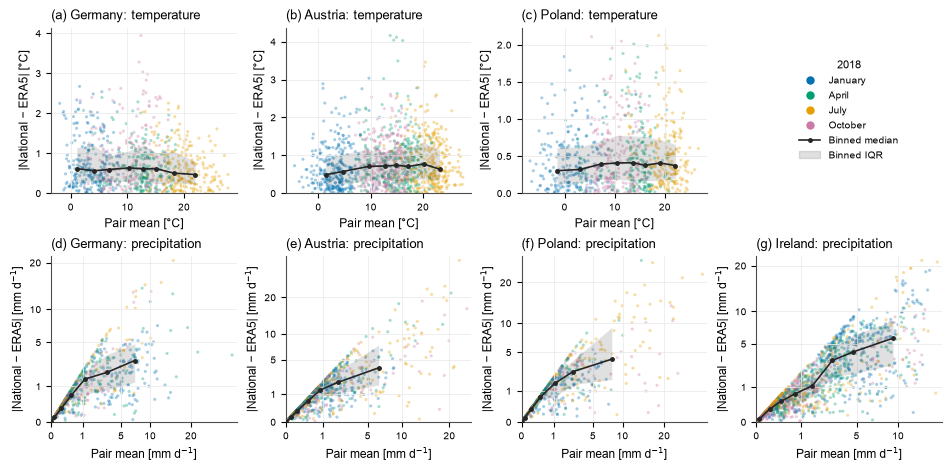

In [24]:
def plot_error_dispersion(pairs, path_stem=None, bins=8):
    """Absolute national - ERA5 difference against the pair mean, by season.

    Points: individual pairs. Line and band: median and IQR of the absolute
    difference within quantile bins of the pair mean. Precipitation uses
    square-root axes, as in the scatter figure. Uses PAPER_STYLE (scaling cell)
    and the region/season styling and helpers of the scatter-plot cell.
    """
    data = pairs.assign(pair_mean=(pairs["value_a"] + pairs["value_b"]) / 2,
                        abs_difference=pairs["difference"].abs())
    variables = [v for v in VARIABLES if v in set(data["variable"])]
    regions = [r for r in REGION_ORDER if r in set(data["region"])]
    with plt.style.context("default"), plt.rc_context(PAPER_STYLE):
        fig, axes = plt.subplots(len(variables), len(regions),
                                 figsize=(2.35 * len(regions), 2.3 * len(variables)),
                                 squeeze=False, constrained_layout=True)
        letters = iter("abcdefghijklmnop")
        empty = []
        for row, variable in enumerate(variables):
            label, unit = VARIABLES[variable]
            for col, region in enumerate(regions):
                ax = axes[row, col]
                sub = data[(data["variable"] == variable) & (data["region"] == region)]
                if sub.empty:
                    ax.set_axis_off()
                    empty.append(ax)
                    continue
                order = np.random.default_rng(0).permutation(len(sub))
                shuffled = sub.iloc[order]
                ax.scatter(shuffled["pair_mean"], shuffled["abs_difference"], s=5, alpha=0.35,
                           linewidths=0, c=shuffled["period"].map(PERIOD_COLOURS), rasterized=True)
                edges = np.unique(np.quantile(sub["pair_mean"], np.linspace(0, 1, bins + 1)))
                binned = sub.assign(bin=pd.cut(sub["pair_mean"], edges, include_lowest=True))
                summary = (binned.groupby("bin", observed=True)
                           .agg(x=("pair_mean", "median"),
                                q1=("abs_difference", lambda s: s.quantile(0.25)),
                                med=("abs_difference", "median"),
                                q3=("abs_difference", lambda s: s.quantile(0.75))))
                ax.fill_between(summary["x"], summary["q1"], summary["q3"], color="0.2",
                                alpha=0.15, linewidth=0, zorder=2)
                ax.plot(summary["x"], summary["med"], color="0.15", linewidth=1.2, marker="o",
                        markersize=2.5, zorder=3)
                if variable in SQRT_VARIABLES:
                    high = float(max(sub["pair_mean"].max(), sub["abs_difference"].max())) * 1.05
                    _sqrt_axes(ax, high)
                    ax.set_xlim(0, float(sub["pair_mean"].max()) * 1.05)
                    ax.set_ylim(0, float(sub["abs_difference"].max()) * 1.05)
                else:
                    ax.set_ylim(bottom=0)
                ax.set_xlabel(f"Pair mean [{unit}]")
                ax.set_ylabel(f"|National − ERA5| [{unit}]")
                ax.set_title(f"({next(letters)}) {REGION_LABELS.get(region, region)}: "
                             f"{label.split()[-1].lower()}", loc="left")
        handles = [Line2D([], [], marker="o", linestyle="", markersize=5, color=c, label=p)
                   for p, c in PERIOD_COLOURS.items()]
        handles.append(Line2D([], [], color="0.15", linewidth=1.2, marker="o", markersize=2.5,
                              label="Binned median"))
        handles.append(Patch(color="0.2", alpha=0.15, label="Binned IQR"))
        if empty:
            empty[0].legend(handles=handles, title="2018", loc="center", frameon=False)
        else:
            fig.legend(handles=handles, title="2018", loc="outside right center", frameon=False)
        if path_stem is not None:
            for suffix in (".pdf", ".png"):
                fig.savefig(Path(str(path_stem) + suffix), bbox_inches="tight")
    return fig


fig = plot_error_dispersion(pairs, FIGURES / "cross_source_error_dispersion")
plt.show()


## 5. Quality reports

Per-source quality reports persisted during this collection (cross-source runs
and the quality-on runs of the overhead experiment).

In [25]:
by_source

,source,n_reports,S2_support_mean,S2_support_median,S2_support_std,S2_support_p05,S2_support_p95,S2_support_min,S2_support_max,S2_support_weighted,...,reports_with_error_values_pct,factor_completeness_mean,factor_completeness_median,factor_completeness_min,factor_completeness_p05,supported_factors_total,returned_output_columns_total,factor_completeness_weighted,reports_with_incomplete_supported_factors,reports_with_incomplete_supported_factors_pct
0,farmwise_api.adapters.API_readers.cds.cds_sing...,48.0,0.564475,0.626059,0.296543,0.170068,0.928571,0.170068,0.928571,0.321552,...,0.0,1.0,1.0,1.0,1.0,84.0,84.0,1.0,0.0,0.0
1,farmwise_api.adapters.API_readers.geosphere.ge...,12.0,0.482379,0.555556,0.213097,0.204082,0.687500,0.204082,0.687500,0.317308,...,0.0,1.0,1.0,1.0,1.0,24.0,24.0,1.0,0.0,0.0
2,farmwise_api.adapters.API_readers.imgw.imgw_ap...,12.0,0.060854,0.039548,0.053997,0.010937,0.132075,0.010937,0.132075,0.024138,...,0.0,1.0,1.0,1.0,1.0,24.0,24.0,1.0,0.0,0.0
3,farmwise_api.adapters.API_readers.irish_meteo....,23.0,0.883808,0.921053,0.055807,0.828396,0.959677,0.828396,0.959677,0.835731,...,0.0,1.0,1.0,1.0,1.0,23.0,23.0,1.0,0.0,0.0
4,farmwise_api.adapters.API_readers.wetterdienst...,12.0,0.296078,0.300000,0.175601,0.088235,0.500000,0.088235,0.500000,0.163158,...,0.0,1.0,1.0,1.0,1.0,24.0,24.0,1.0,0.0,0.0


In [26]:
by_level

,S2_level,n_reports,S2_support_mean,S2_support_median,S2_support_std,S2_support_p05,S2_support_p95,S2_support_min,S2_support_max,S2_support_weighted,...,reports_with_error_values_pct,factor_completeness_mean,factor_completeness_median,factor_completeness_min,factor_completeness_p05,supported_factors_total,returned_output_columns_total,factor_completeness_weighted,reports_with_incomplete_supported_factors,reports_with_incomplete_supported_factors_pct
0,8,32.0,0.726558,0.859080,0.269713,0.132075,0.928571,0.132075,0.928571,0.640625,...,0.0,1.0,1.0,1.0,1.0,56.0,56.0,1.0,0.0,0.0
1,9,32.0,0.535216,0.590278,0.249456,0.039548,0.921053,0.039548,0.921053,0.441667,...,0.0,1.0,1.0,1.0,1.0,56.0,56.0,1.0,0.0,0.0
2,10,43.0,0.398078,0.201613,0.350641,0.010937,0.959677,0.010937,0.959677,0.541186,...,0.0,1.0,1.0,1.0,1.0,67.0,67.0,1.0,0.0,0.0


In [27]:
issue_summary

,source,n_reports,any_quality_issue,partial_spatial_support,missing_days,missing_values,error_values,incomplete_supported_factors,any_quality_issue_pct,partial_spatial_support_pct,missing_days_pct,missing_values_pct,error_values_pct,incomplete_supported_factors_pct
0,farmwise_api.adapters.API_readers.cds.cds_sing...,48,0,48,0,0,0,0,0.0,100.0,0.0,0.0,0.0,0.0
1,farmwise_api.adapters.API_readers.geosphere.ge...,12,0,12,0,0,0,0,0.0,100.0,0.0,0.0,0.0,0.0
2,farmwise_api.adapters.API_readers.imgw.imgw_ap...,12,0,12,0,0,0,0,0.0,100.0,0.0,0.0,0.0,0.0
3,farmwise_api.adapters.API_readers.irish_meteo....,23,0,23,0,0,0,0,0.0,100.0,0.0,0.0,0.0,0.0
4,farmwise_api.adapters.API_readers.wetterdienst...,12,0,12,0,0,0,0,0.0,100.0,0.0,0.0,0.0,0.0
